In [1]:
from pathlib import Path
import os
import json
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

In [2]:
DATA_DIR = Path("/kaggle/input/competitions/pixels-to-predictions")

train_df = pd.read_csv(DATA_DIR / "train.csv")
val_df = pd.read_csv(DATA_DIR / "val.csv")
test_df = pd.read_csv(DATA_DIR / "test.csv")
sample_submission = pd.read_csv(DATA_DIR / "sample_submission.csv")

# Convert choices from JSON string to Python list
for df in [train_df, val_df, test_df]:
    df["choices"] = df["choices"].apply(json.loads)

print("train:", train_df.shape)
print("val:", val_df.shape)
print("test:", test_df.shape)
print("sample submission:", sample_submission.shape)

print("\nTrain columns:")
print(train_df.columns.tolist())

display(train_df.head(3))
display(val_df.head(3))
display(test_df.head(3))

train: (3109, 15)
val: (1048, 15)
test: (1008, 13)
sample submission: (1008, 2)

Train columns:
['id', 'image_path', 'question', 'choices', 'num_choices', 'answer', 'hint', 'lecture', 'solution', 'task', 'grade', 'subject', 'topic', 'category', 'skill']


,id,image_path,question,choices,num_choices,answer,hint,lecture,solution,task,grade,subject,topic,category,skill
0,train_07667,images/train/train_07667.png,Why might putting each tadpole in its own pool...,[the male's tadpoles will be larger when they ...,3,2,Animals often behave in certain ways that can ...,Animals increase their reproductive success wh...,Look for the part of the passage that describe...,closed choice,grade8,natural science,literacy-in-science,Adaptations and natural selection,How can animal behaviors affect reproductive s...
1,train_02628,images/train/train_02628.png,Why might forming strong social bonds with oth...,"[the female's offspring will live longer, the ...",3,0,Animals often behave in certain ways that can ...,Animals increase their reproductive success wh...,Look for the part of the passage that describe...,closed choice,grade8,natural science,literacy-in-science,Adaptations and natural selection,How can animal behaviors affect reproductive s...
2,train_00927,images/train/train_00927.png,Why might raising cubs with other lionesses in...,"[the lioness's cubs will be around other cubs,...",3,1,Animals often behave in certain ways that can ...,Animals increase their reproductive success wh...,Look for the part of the passage that describe...,closed choice,grade8,natural science,literacy-in-science,Adaptations and natural selection,How can animal behaviors affect reproductive s...


,id,image_path,question,choices,num_choices,answer,hint,lecture,solution,task,grade,subject,topic,category,skill
0,val_00671,images/val/val_00671.png,Why might covering its eggs with its body incr...,"[the leech's eggs will hatch, the leech will n...",3,0,Animals often behave in certain ways that can ...,Animals increase their reproductive success wh...,Look for the part of the passage that describe...,closed choice,grade8,natural science,literacy-in-science,Adaptations and natural selection,How can animal behaviors affect reproductive s...
1,val_04111,images/val/val_04111.png,Why might fanning eggs increase the reproducti...,[the male will build a nest for females to lay...,3,1,Animals often behave in certain ways that can ...,Animals increase their reproductive success wh...,Look for the part of the passage that describe...,closed choice,grade8,natural science,literacy-in-science,Adaptations and natural selection,How can animal behaviors affect reproductive s...
2,val_02022,images/val/val_02022.png,"Based on clues in the text, how did fossil evi...",[It helped scientists learn that beetle specie...,4,3,Read the text about beetles.\nThere are more s...,"Informational texts include many facts, exampl...",Think about these details from the text:\nFoss...,closed choice,grade5,language science,reading-comprehension,Informational texts: level 1,Read passages about animals


,id,image_path,question,choices,num_choices,hint,lecture,task,grade,subject,topic,category,skill
0,test_01750,images/test/test_01750.png,"Based on clues in the text, why would farmers ...",[The cats were thought to be visiting goddesse...,4,Read the text about cats.\nCats are among the ...,"Informational texts include many facts, exampl...",closed choice,grade5,language science,reading-comprehension,Informational texts: level 1,Read passages about animals
1,test_00128,images/test/test_00128.png,What is the probability that an American curl ...,"[0/4, 2/4, 4/4, 3/4, 1/4]",5,"In a group of American curl cats, some individ...",Offspring genotypes: homozygous or heterozygou...,closed choice,grade8,natural science,biology,Genes to traits,Use Punnett squares to calculate probabilities...
2,test_02891,images/test/test_02891.png,What is the expected ratio of offspring with a...,"[4:0, 3:1, 1:3, 0:4, 2:2]",5,This passage describes the ground spot color t...,Offspring phenotypes: dominant or recessive?\n...,closed choice,grade8,natural science,biology,Genes to traits,Use Punnett squares to calculate ratios of off...


In [3]:
def get_image_path(row):
    rel_path = Path(row["image_path"])

    # CSV: images/train/xxx.png
    # Real: DATA_DIR/images/images/train/xxx.png
    p = DATA_DIR / "images" / rel_path
    if p.exists():
        return p

    # fallback 1: direct path
    p = DATA_DIR / rel_path
    if p.exists():
        return p

    # fallback 2: search by filename
    matches = list(DATA_DIR.rglob(rel_path.name))
    if len(matches) > 0:
        return matches[0]

    raise FileNotFoundError(f"Could not find image: {row['image_path']}")

fixed image path: /kaggle/input/competitions/pixels-to-predictions/images/images/train/train_07667.png
exists: True
image size: (302, 252)


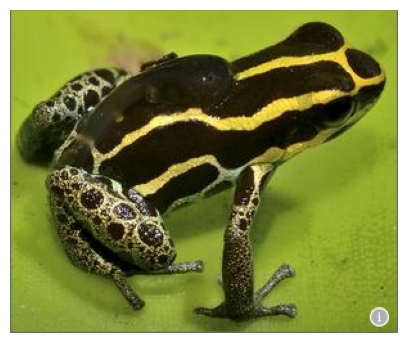

In [4]:
row = train_df.iloc[0]

img_path = get_image_path(row)
print("fixed image path:", img_path)
print("exists:", img_path.exists())

img = Image.open(img_path).convert("RGB")
print("image size:", img.size)

plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.axis("off")
plt.show()

In [5]:
LETTERS = "ABCDEFGHIJKLMNOPQRSTUVWXYZ"

def clean_text(x):
    if pd.isna(x):
        return ""
    return str(x).strip()

def index_to_letter(idx):
    return LETTERS[int(idx)]

def letter_to_index(letter):
    return LETTERS.index(letter.upper())

def build_prompt(row, include_answer=False):
    choices = row["choices"]
    
    choice_lines = []
    for i, choice in enumerate(choices):
        choice_lines.append(f"{LETTERS[i]}. {choice}")
    choices_text = "\n".join(choice_lines)

    parts = []

    for col in ["grade", "subject", "topic", "category", "skill"]:
        if col in row and clean_text(row[col]):
            parts.append(f"{col.capitalize()}: {clean_text(row[col])}")

    if "lecture" in row and clean_text(row["lecture"]):
        parts.append(f"Lecture:\n{clean_text(row['lecture'])}")

    if "hint" in row and clean_text(row["hint"]):
        parts.append(f"Hint:\n{clean_text(row['hint'])}")

    parts.append(f"Question:\n{clean_text(row['question'])}")
    parts.append(f"Choices:\n{choices_text}")

    valid_letters = ", ".join(LETTERS[:int(row["num_choices"])])
    parts.append(f"Answer with only one letter: {valid_letters}.")
    parts.append("Answer:")

    prompt = "\n\n".join(parts)

    if include_answer:
        prompt += f" {index_to_letter(row['answer'])}"

    return prompt

In [6]:
row = train_df.iloc[0]
print(build_prompt(row, include_answer=True))

Grade: grade8

Subject: natural science

Topic: literacy-in-science

Category: Adaptations and natural selection

Skill: How can animal behaviors affect reproductive success? Identify evidence to support a claim

Lecture:
Animals increase their reproductive success when they have offspring that survive to reproduce.
Animals can increase their chances of having offspring by behaving in ways that help them get partners to mate and reproduce with. These partners are called mates. For example, animals may make special sounds, perform specific dances, or show off bright colors to attract mates. Animals may also compete with each other for mates.
Animals can increase the chances that their offspring will survive to reproduce by caring for and protecting them. For example, animals may feed their offspring or guard them from predators. These behaviors increase the chances that the offspring will survive to adulthood, when they can reproduce.
Many behaviors can increase the chances that animals

In [7]:
import torch
from transformers import AutoProcessor, AutoModelForImageTextToText

MODEL_ID = "HuggingFaceTB/SmolVLM-500M-Instruct"

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

processor = AutoProcessor.from_pretrained(MODEL_ID)

model = AutoModelForImageTextToText.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16 if device == "cuda" else torch.float32,
    device_map="auto" if device == "cuda" else None,
)

model.eval()

device: cuda


processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/429 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/486 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/1.02G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/489 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/136 [00:00<?, ?B/s]

Idefics3ForConditionalGeneration(
  (model): Idefics3Model(
    (vision_model): Idefics3VisionTransformer(
      (embeddings): Idefics3VisionEmbeddings(
        (patch_embedding): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16), padding=valid)
        (position_embedding): Embedding(1024, 768)
      )
      (encoder): Idefics3Encoder(
        (layers): ModuleList(
          (0-11): 12 x Idefics3EncoderLayer(
            (self_attn): Idefics3VisionAttention(
              (k_proj): Linear(in_features=768, out_features=768, bias=True)
              (v_proj): Linear(in_features=768, out_features=768, bias=True)
              (q_proj): Linear(in_features=768, out_features=768, bias=True)
              (out_proj): Linear(in_features=768, out_features=768, bias=True)
            )
            (layer_norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
            (mlp): Idefics3VisionMLP(
              (activation_fn): GELUTanh()
              (fc1): Linear(in_features=768, out

In [8]:
row = val_df.iloc[0]

prompt = build_prompt(row, include_answer=False)
image = Image.open(get_image_path(row)).convert("RGB")

messages = [
    {
        "role": "user",
        "content": [
            {"type": "image"},
            {"type": "text", "text": prompt},
        ],
    }
]

text = processor.apply_chat_template(
    messages,
    add_generation_prompt=True,
)

inputs = processor(
    text=text,
    images=image,
    return_tensors="pt",
).to(model.device)

with torch.no_grad():
    generated_ids = model.generate(
        **inputs,
        max_new_tokens=10,
        do_sample=False,
    )

# Only keep newly generated tokens
new_tokens = generated_ids[:, inputs["input_ids"].shape[1]:]

generated_text = processor.batch_decode(
    new_tokens,
    skip_special_tokens=True
)[0]

print("Ground truth:", row["answer"])
print("Generated answer only:")
print(generated_text)

Ground truth: 0
Generated answer only:
 Answer: B


In [14]:
import re
from tqdm.auto import tqdm

def extract_answer_index(text, num_choices):
    text = str(text).strip().upper()
    valid_letters = LETTERS[:int(num_choices)]

    # Prefer outputs like "Answer: B"
    m = re.search(r"ANSWER\s*[:\-]?\s*([A-Z])", text)
    if m:
        letter = m.group(1)
        if letter in valid_letters:
            return letter_to_index(letter)

    # Then look for a standalone letter like "B"
    m = re.search(r"\b([A-Z])\b", text)
    if m:
        letter = m.group(1)
        if letter in valid_letters:
            return letter_to_index(letter)

    # Fallback: if model outputs a valid integer index
    nums = re.findall(r"\d+", text)
    for n in nums:
        ans = int(n)
        if 0 <= ans < int(num_choices):
            return ans

    return 0

In [20]:
def predict_one(row, max_new_tokens=10):
    prompt = build_prompt(row, include_answer=False)
    image = Image.open(get_image_path(row)).convert("RGB")

    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image"},
                {"type": "text", "text": prompt},
            ],
        }
    ]

    text = processor.apply_chat_template(
        messages,
        add_generation_prompt=True,
    )

    inputs = processor(
        text=text,
        images=image,
        return_tensors="pt",
    ).to(model.device)

    with torch.no_grad():
        generated_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
        )

    new_tokens = generated_ids[:, inputs["input_ids"].shape[1]:]

    generated_text = processor.batch_decode(
        new_tokens,
        skip_special_tokens=True
    )[0]

    pred = extract_answer_index(generated_text, row["num_choices"])
    return pred, generated_text

In [21]:
model.eval()

n = 20
correct = 0
records = []

for i in tqdm(range(n)):
    row = val_df.iloc[i]
    pred, raw = predict_one(row)
    true = int(row["answer"])
    correct += int(pred == true)

    records.append({
        "id": row["id"],
        "pred": pred,
        "true": true,
        "raw": raw,
        "correct": pred == true,
    })

acc = correct / n
print("zero-shot val accuracy on", n, "samples:", acc)

pd.DataFrame(records)

  0%|          | 0/20 [00:00<?, ?it/s]

zero-shot val accuracy on 20 samples: 0.35


,id,pred,true,raw,correct
0,val_00671,1,0,Answer: B,False
1,val_04111,0,1,Answer: A,False
2,val_02022,0,3,Answer: A,False
3,val_01237,1,0,Answer: B,False
4,val_03458,1,4,Answer: B,False
5,val_04064,3,3,Answer: D,True
6,val_03959,0,4,Answer: A,False
7,val_03289,0,2,Answer: A,False
8,val_03452,1,3,Answer: B,False
9,val_01021,0,0,Answer: A,True


In [24]:
from peft import LoraConfig, get_peft_model, TaskType

# Only target text_model layers, not vision_model layers
target_suffixes = [
    "q_proj", "k_proj", "v_proj", "o_proj",
    "gate_proj", "up_proj", "down_proj"
]

target_modules = []
for name, module in model.named_modules():
    if name.startswith("model.text_model") and any(name.endswith(s) for s in target_suffixes):
        target_modules.append(name)

print("Number of target modules:", len(target_modules))
print(target_modules[:10])
print(target_modules[-10:])

lora_config = LoraConfig(
    r=4,
    lora_alpha=16,
    target_modules=target_modules,
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.CAUSAL_LM,
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

Number of target modules: 224
['model.text_model.layers.0.self_attn.q_proj', 'model.text_model.layers.0.self_attn.k_proj', 'model.text_model.layers.0.self_attn.v_proj', 'model.text_model.layers.0.self_attn.o_proj', 'model.text_model.layers.0.mlp.gate_proj', 'model.text_model.layers.0.mlp.up_proj', 'model.text_model.layers.0.mlp.down_proj', 'model.text_model.layers.1.self_attn.q_proj', 'model.text_model.layers.1.self_attn.k_proj', 'model.text_model.layers.1.self_attn.v_proj']
['model.text_model.layers.30.mlp.gate_proj', 'model.text_model.layers.30.mlp.up_proj', 'model.text_model.layers.30.mlp.down_proj', 'model.text_model.layers.31.self_attn.q_proj', 'model.text_model.layers.31.self_attn.k_proj', 'model.text_model.layers.31.self_attn.v_proj', 'model.text_model.layers.31.self_attn.o_proj', 'model.text_model.layers.31.mlp.gate_proj', 'model.text_model.layers.31.mlp.up_proj', 'model.text_model.layers.31.mlp.down_proj']
trainable params: 2,170,880 || all params: 509,653,184 || trainable%: 0

In [30]:
from torch.utils.data import Dataset
from transformers import TrainingArguments, Trainer

class VQADataset(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(get_image_path(row)).convert("RGB")

        user_prompt = build_prompt(row, include_answer=False)
        answer_letter = index_to_letter(row["answer"])

        full_messages = [
            {
                "role": "user",
                "content": [
                    {"type": "image"},
                    {"type": "text", "text": user_prompt},
                ],
            },
            {
                "role": "assistant",
                "content": [
                    {"type": "text", "text": answer_letter},
                ],
            },
        ]

        prompt_messages = [
            {
                "role": "user",
                "content": [
                    {"type": "image"},
                    {"type": "text", "text": user_prompt},
                ],
            }
        ]

        full_text = processor.apply_chat_template(
            full_messages,
            add_generation_prompt=False,
        )

        prompt_text = processor.apply_chat_template(
            prompt_messages,
            add_generation_prompt=True,
        )

        return {
            "full_text": full_text,
            "prompt_text": prompt_text,
            "image": image,
        }


def collate_fn(batch):
    full_texts = [item["full_text"] for item in batch]
    prompt_texts = [item["prompt_text"] for item in batch]
    images = [item["image"] for item in batch]

    inputs = processor(
        text=full_texts,
        images=images,
        return_tensors="pt",
        padding=True,
    )

    prompt_inputs = processor(
        text=prompt_texts,
        images=images,
        return_tensors="pt",
        padding=True,
    )

    labels = inputs["input_ids"].clone()

    # Mask padding tokens
    if processor.tokenizer.pad_token_id is not None:
        labels[labels == processor.tokenizer.pad_token_id] = -100

    # Mask the user prompt part, only train on assistant answer
    for i in range(len(batch)):
        prompt_len = prompt_inputs["attention_mask"][i].sum().item()
        labels[i, :prompt_len] = -100

    inputs["labels"] = labels
    return inputs

In [31]:
train_small = train_df.sample(n=200, random_state=42)
train_dataset_small = VQADataset(train_small)

training_args = TrainingArguments(
    output_dir="/kaggle/working/smolvlm_lora_test_v2",
    per_device_train_batch_size=1,
    gradient_accumulation_steps=8,
    num_train_epochs=1,
    learning_rate=2e-4,
    logging_steps=5,
    save_steps=100,
    save_total_limit=1,
    fp16=True,
    report_to="none",
    remove_unused_columns=False,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset_small,
    data_collator=collate_fn,
)

trainer.train()

Step,Training Loss
5,9.577394
10,5.385651
15,1.634248
20,0.667268
25,0.264970


TrainOutput(global_step=25, training_loss=3.505906229019165, metrics={'train_runtime': 372.4406, 'train_samples_per_second': 0.537, 'train_steps_per_second': 0.067, 'total_flos': 707989281268224.0, 'train_loss': 3.505906229019165, 'epoch': 1.0})

In [32]:
model.eval()

n = 20
correct = 0
records = []

for i in tqdm(range(n)):
    row = val_df.iloc[i]
    pred, raw = predict_one(row)
    true = int(row["answer"])
    correct += int(pred == true)

    records.append({
        "id": row["id"],
        "pred": pred,
        "true": true,
        "raw": raw,
        "correct": pred == true,
    })

acc = correct / n
print("small-LoRA-v2 val accuracy on", n, "samples:", acc)

pd.DataFrame(records)

  0%|          | 0/20 [00:00<?, ?it/s]

small-LoRA-v2 val accuracy on 20 samples: 0.3


,id,pred,true,raw,correct
0,val_00671,1,0,B,False
1,val_04111,0,1,A,False
2,val_02022,0,3,A,False
3,val_01237,1,0,B,False
4,val_03458,4,4,E,True
5,val_04064,3,3,D,True
6,val_03959,0,4,A,False
7,val_03289,0,2,A,False
8,val_03452,4,3,E,False
9,val_01021,0,0,A,True
